# graphical models

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [2]:
import daft

<Axes: >

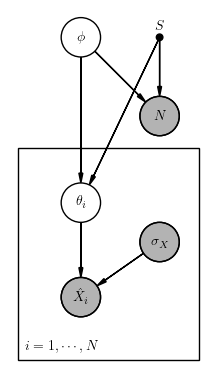

In [20]:
pgm = daft.PGM(observed_style='shaded')

# population parameters (what we want to infer)
pgm.add_node('phi', r'$\phi$', 1.5, 3.6)

# survey: selection function + noise model (fixed/given)
pgm.add_node('S', r'$S$', 2.5, 3.6, fixed=True, offset=(0, 0))

# total number of detected galaxies
pgm.add_node('N', r'$N$', 2.5, 2.6, observed=True)

# per-galaxy true source properties (latent)
pgm.add_node('zM', r'$\theta_i$', 1.5, 1.5)#, aspect=2.2)

# per-galaxy noise levels (observed, set by the survey)
pgm.add_node('sigma', r'$\sigma_X$', 2.5, 1, observed=True)#, aspect=2.2)

# observed photometric redshift and magnitude
pgm.add_node('X', r'$\hat{X}_i$', 1.5, 0.3, observed=True)#, aspect=2.2)

# edges
pgm.add_edge('phi', 'N')
#pgm.add_edge('N', 'zM')
pgm.add_edge('S', 'N')
pgm.add_edge('S', 'zM')
pgm.add_edge('phi', 'zM')

pgm.add_edge('zM', 'X')
pgm.add_edge('sigma', 'X')

# plate over the N detected galaxies
pgm.add_plate(daft.Plate([0.7, -0.4, 2.3, 2.6], label=r'$i = 1, \cdots, N$', shift=-0.1))

pgm.render()
#pgm.savefig(fout, dpi=150)
#print('wrote', fout)
